# Oregon FARS Master Dataset EDA

Exploratory data analysis for `OregonFARSMaster.csv`.

This notebook is designed for the project dataset built from NHTSA FARS tables for Oregon fatal pedestrian/cyclist crashes from 2015-2024.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Update this path if needed
DATA_PATH = Path("FARSmaster.csv")

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()


Rows: 1,049
Columns: 38


,ST_CASE,PER_NO,AGE,SEXNAME,PBPTYPENAME,YEAR,MONTHNAME,DAY_WEEKNAME,HOURNAME,LGT_CONDNAME,WEATHER,RUR_URBNAME,FUNC_SYSNAME,TYP_INTNAME,REL_ROADNAME,WRK_ZONENAME,LATITUDE,LONGITUD,PEDLOCNAME,BIKELOCNAME,PEDPOSNAME,BIKEPOSNAME,PEDDIRNAME,BIKEDIRNAME,VSPD_LIM,VSPD_LIMNAME,VTRAFCON,VTRAFCONNAME,VTRAFWAY,VTRAFWAYNAME,GEOID,NAMELSAD,MEDIAN_INCOME,TOTAL_POPULATION,PCT_WHITE,PCT_BLACK,PCT_HISPANIC,PCT_TRANSIT_WALK_COMMUTE
0,410001,1,66,Female,Persons on Personal Conveyances,2015,January,Thursday,6:00am-6:59am,Dark - Lighted,Clear,Urban,Major Collector,Not an Intersection,On Roadway,None / Unknown,45.096200,-123.424297,Not At Intersection,Not a Cyclist,Travel Lane,Not a Cyclist,Not Applicable,Not a Cyclist,45,45 MPH,0,No Controls,1,"Two-Way, Not Divided",41071030502,Census Tract 305.02,49134.0,5033,84.681105,0.139082,6.218955,9.751037
1,410003,1,64,Male,Pedestrian,2015,January,Thursday,6:00pm-6:59pm,Dark - Not Lighted,Clear,Urban,Principal Arterial - Other,T-Intersection,On Roadway,None / Unknown,45.476617,-122.534667,At Intersection,Not a Cyclist,Intersection Area,Not a Cyclist,Northbound,Not a Cyclist,35,35 MPH,0,No Controls,1,"Two-Way, Not Divided",41051008904,Census Tract 89.04,65137.0,4908,54.013855,6.438468,18.887531,4.925054
2,410006,1,64,Male,Pedestrian,2015,January,Monday,5:00pm-5:59pm,Dark - Lighted,Cloudy,Urban,Principal Arterial - Other,Not an Intersection,On Roadway,None / Unknown,44.950183,-122.993433,Not At Intersection,Not a Cyclist,Sidewalk / Shared-Use Path / Driveway Access,Not a Cyclist,Not Applicable,Not a Cyclist,30,30 MPH,0,No Controls,5,"Two-Way, Not Divided With a Continuous Left-Tu...",41047000703,Census Tract 7.03,56500.0,2626,52.513328,1.447068,34.843869,3.308824
3,410006,2,63,Female,Pedestrian,2015,January,Monday,5:00pm-5:59pm,Dark - Lighted,Cloudy,Urban,Principal Arterial - Other,Not an Intersection,On Roadway,None / Unknown,44.950183,-122.993433,Not At Intersection,Not a Cyclist,Sidewalk / Shared-Use Path / Driveway Access,Not a Cyclist,Not Applicable,Not a Cyclist,30,30 MPH,0,No Controls,5,"Two-Way, Not Divided With a Continuous Left-Tu...",41047000703,Census Tract 7.03,56500.0,2626,52.513328,1.447068,34.843869,3.308824
4,410008,1,50,Male,Pedestrian,2015,January,Sunday,5:00pm-5:59pm,Dark - Not Lighted,Cloudy,Urban,Principal Arterial - Other,Not an Intersection,On Roadway,None / Unknown,44.587275,-123.253944,Not At Intersection,Not a Cyclist,Travel Lane,Not a Cyclist,Not Applicable,Not a Cyclist,50,50 MPH,0,No Controls,1,"Two-Way, Not Divided",41003000600,Census Tract 6,52371.0,4634,82.757877,1.251618,9.063444,3.214971


## 1. Basic structure

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1049 entries, 0 to 1048
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ST_CASE                   1049 non-null   int64  
 1   PER_NO                    1049 non-null   int64  
 2   AGE                       1049 non-null   int64  
 3   SEXNAME                   1049 non-null   object 
 4   PBPTYPENAME               1049 non-null   object 
 5   YEAR                      1049 non-null   int64  
 6   MONTHNAME                 1049 non-null   object 
 7   DAY_WEEKNAME              1049 non-null   object 
 8   HOURNAME                  1049 non-null   object 
 9   LGT_CONDNAME              1049 non-null   object 
 10  WEATHER                   1049 non-null   object 
 11  RUR_URBNAME               1049 non-null   object 
 12  FUNC_SYSNAME              1049 non-null   object 
 13  TYP_INTNAME               1049 non-null   object 
 14  REL_ROAD

In [11]:
df[df.columns[::-1]].describe(include="all")

,PCT_TRANSIT_WALK_COMMUTE,PCT_HISPANIC,PCT_BLACK,PCT_WHITE,TOTAL_POPULATION,MEDIAN_INCOME,NAMELSAD,GEOID,VTRAFWAYNAME,VTRAFWAY,VTRAFCONNAME,VTRAFCON,VSPD_LIMNAME,VSPD_LIM,BIKEDIRNAME,PEDDIRNAME,BIKEPOSNAME,PEDPOSNAME,BIKELOCNAME,PEDLOCNAME,LONGITUD,LATITUDE,WRK_ZONENAME,REL_ROADNAME,TYP_INTNAME,FUNC_SYSNAME,RUR_URBNAME,WEATHER,LGT_CONDNAME,HOURNAME,DAY_WEEKNAME,MONTHNAME,YEAR,PBPTYPENAME,SEXNAME,AGE,PER_NO,ST_CASE
count,1048.000000,1048.000000,1048.000000,1048.000000,1049.000000,1043.000000,1049,1.049000e+03,1049,1049.000000,1049,1049.000000,1049,1049.000000,1049,1049,1049,1049,1049,1049,1049.000000,1049.000000,1049,1049,1049,1049,1049,1049,1049,1049,1049,1049,1049.000000,1049,1049,1049.000000,1049.000000,1049.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,394,NaN,9,NaN,12,NaN,14,NaN,5,8,6,9,5,6,NaN,NaN,3,9,7,10,3,16,9,25,7,12,NaN,8,2,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,Census Tract 2,NaN,"Two-Way, Not Divided",NaN,Not Reported,NaN,Not Reported,NaN,Not a Cyclist,Not Applicable,Not a Cyclist,Travel Lane,Not a Cyclist,Not At Intersection,NaN,NaN,None / Unknown,On Roadway,Not an Intersection,Principal Arterial - Other,Urban,Clear,Dark - Lighted,6:00pm-6:59pm,Friday,November,NaN,Pedestrian,Male,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,14,NaN,553,NaN,593,NaN,248,NaN,924,668,924,554,924,643,NaN,NaN,1024,932,741,387,863,476,344,95,168,125,NaN,881,714,NaN,NaN,NaN
mean,7.623522,15.804702,2.432044,70.282507,4497.125834,71212.451582,NaN,4.104043e+10,NaN,2.584366,NaN,56.121068,NaN,55.232602,NaN,NaN,NaN,NaN,NaN,NaN,-122.637832,44.759223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.902765,NaN,NaN,48.890372,1.064824,410265.651096
std,7.734087,12.394702,3.932707,15.572537,1572.371074,22981.895290,NaN,1.842031e+07,NaN,1.946023,NaN,46.985823,NaN,26.154547,NaN,NaN,NaN,NaN,NaN,NaN,0.973194,1.075255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.851958,NaN,NaN,19.063484,0.346179,162.268538
min,0.000000,0.000000,0.000000,5.119454,0.000000,23765.000000,NaN,4.100195e+10,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,-124.415256,42.006975,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN,NaN,1.000000,1.000000,410001.000000
25%,2.381505,7.374718,0.067889,59.272268,3358.000000,55648.000000,NaN,4.102900e+10,NaN,1.000000,NaN,0.000000,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,-123.042231,44.088144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,35.000000,1.000000,410109.000000
50%,5.155211,12.253910,0.705612,73.293469,4432.000000,68333.000000,NaN,4.104700e+10,NaN,1.000000,NaN,97.000000,NaN,45.000000,NaN,NaN,NaN,NaN,NaN,NaN,-122.788111,45.358989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,NaN,50.000000,1.000000,410279.000000
75%,10.185255,21.149305,2.805592,82.757877,5519.000000,82860.000000,NaN,4.105101e+10,NaN,5.000000,NaN,97.000000,NaN,65.000000,NaN,NaN,NaN,NaN,NaN,NaN,-122.537658,45.519172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,NaN,NaN,63.000000,1.000000,410401.000000


## 2. Missingness and duplicates

In [12]:
missing = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
    .sort_values("missing_pct", ascending=False)
)

missing


,missing_count,missing_pct
MEDIAN_INCOME,6,0.571973
PCT_TRANSIT_WALK_COMMUTE,1,0.095329
PCT_HISPANIC,1,0.095329
PCT_BLACK,1,0.095329
PCT_WHITE,1,0.095329
VTRAFCON,0,0.000000
BIKEPOSNAME,0,0.000000
PEDDIRNAME,0,0.000000
BIKEDIRNAME,0,0.000000
VSPD_LIM,0,0.000000


In [13]:
print(f"Duplicate rows: {df.duplicated().sum():,}")

Duplicate rows: 0


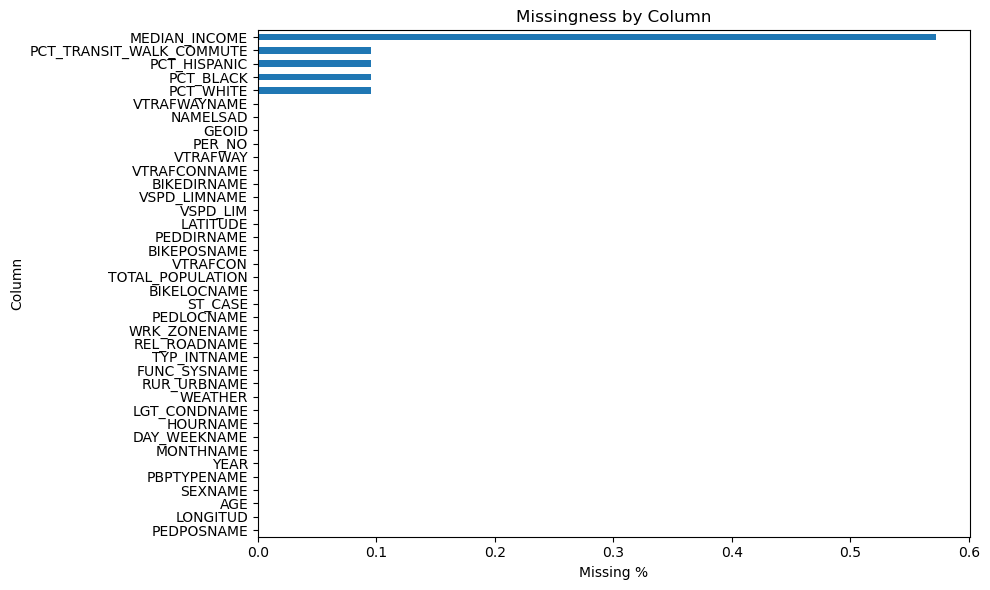

In [14]:
plt.figure(figsize=(10, 6))
missing["missing_pct"].sort_values().plot(kind="barh")
plt.title("Missingness by Column")
plt.xlabel("Missing %")
plt.ylabel("Column")
plt.tight_layout()
plt.show()


## 3. Helper functions

In [30]:
def plot_bar(series, title, xlabel="", ylabel="Count", top_n=None, horizontal=False):
    counts = series.value_counts(dropna=False)

    if top_n:
        counts = counts.head(top_n)

    plt.figure(figsize=(10, 5))

    if horizontal:
        counts.sort_values().plot(kind="barh")
        plt.xlabel(ylabel)
        plt.ylabel(xlabel)
    else:
        counts.plot(kind="bar")
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.xticks(rotation=45, ha="right")

    plt.title(title)
    plt.tight_layout()
    plt.show()


def column_exists(col):
    return col in df.columns

def plot_bar(series, title, xlabel="", ylabel="Count", top_n=None, horizontal=False):
    counts = series.value_counts(dropna=False)

    if top_n:
        counts = counts.head(top_n)

    plt.figure(figsize=(10, 5))

    if horizontal:
        ax = counts.sort_values().plot(kind="barh")
        ax.bar_label(ax.containers[0], padding=3)
        plt.xlabel(ylabel)
        plt.ylabel(xlabel)
    else:
        ax = counts.plot(kind="bar")
        ax.bar_label(ax.containers[0], padding=3)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.xticks(rotation=45, ha="right")

    plt.title(title)
    plt.tight_layout()
    plt.show()

## 4. Time patterns

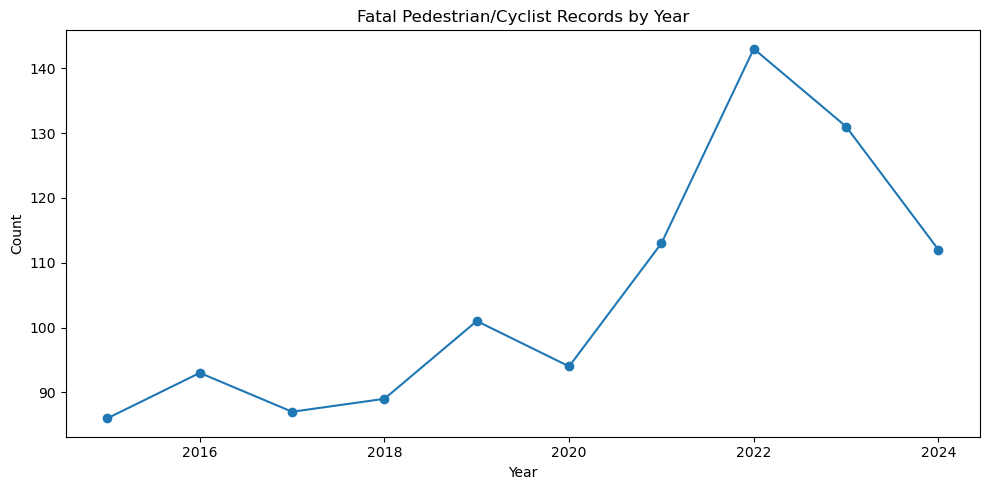

,count
YEAR,
2015,86
2016,93
2017,87
2018,89
2019,101
2020,94
2021,113
2022,143
2023,131


In [16]:
if column_exists("YEAR"):
    year_counts = df["YEAR"].value_counts().sort_index()

    plt.figure(figsize=(10, 5))
    year_counts.plot(marker="o")
    plt.title("Fatal Pedestrian/Cyclist Records by Year")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    display(year_counts.to_frame("count"))


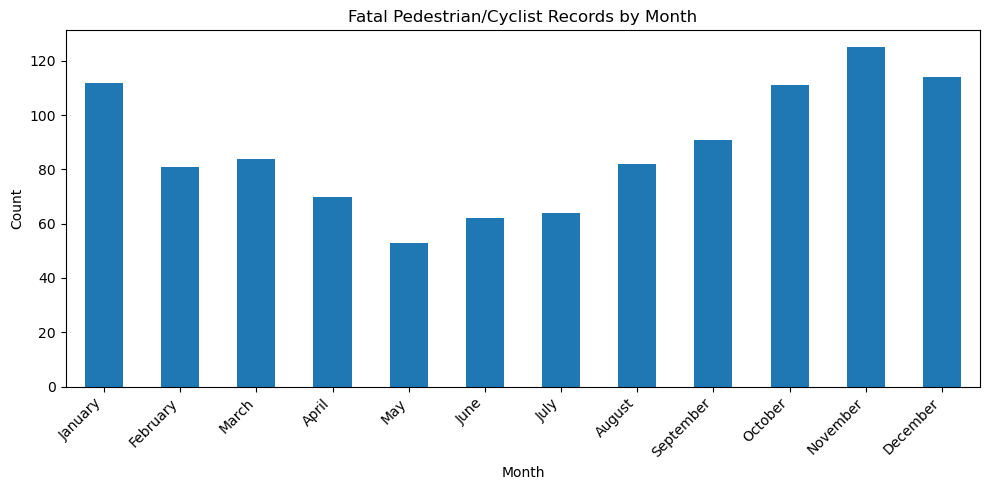

,count
MONTHNAME,
January,112
February,81
March,84
April,70
May,53
June,62
July,64
August,82
September,91


In [17]:
if column_exists("MONTHNAME"):
    month_order = [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"
    ]

    month_counts = df["MONTHNAME"].value_counts().reindex(month_order)

    plt.figure(figsize=(10, 5))
    month_counts.plot(kind="bar")
    plt.title("Fatal Pedestrian/Cyclist Records by Month")
    plt.xlabel("Month")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(month_counts.to_frame("count"))


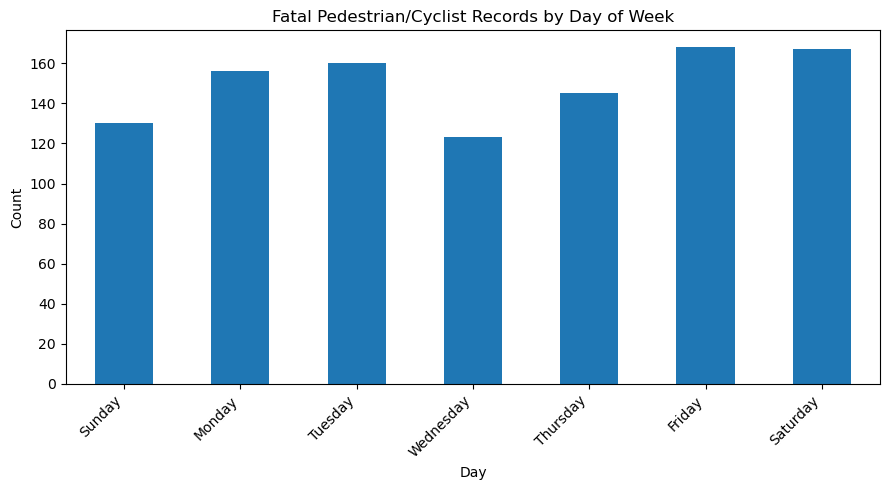

,count
DAY_WEEKNAME,
Sunday,130
Monday,156
Tuesday,160
Wednesday,123
Thursday,145
Friday,168
Saturday,167


In [18]:
if column_exists("DAY_WEEKNAME"):
    day_order = [
        "Sunday", "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday"
    ]

    day_counts = df["DAY_WEEKNAME"].value_counts().reindex(day_order)

    plt.figure(figsize=(9, 5))
    day_counts.plot(kind="bar")
    plt.title("Fatal Pedestrian/Cyclist Records by Day of Week")
    plt.xlabel("Day")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(day_counts.to_frame("count"))


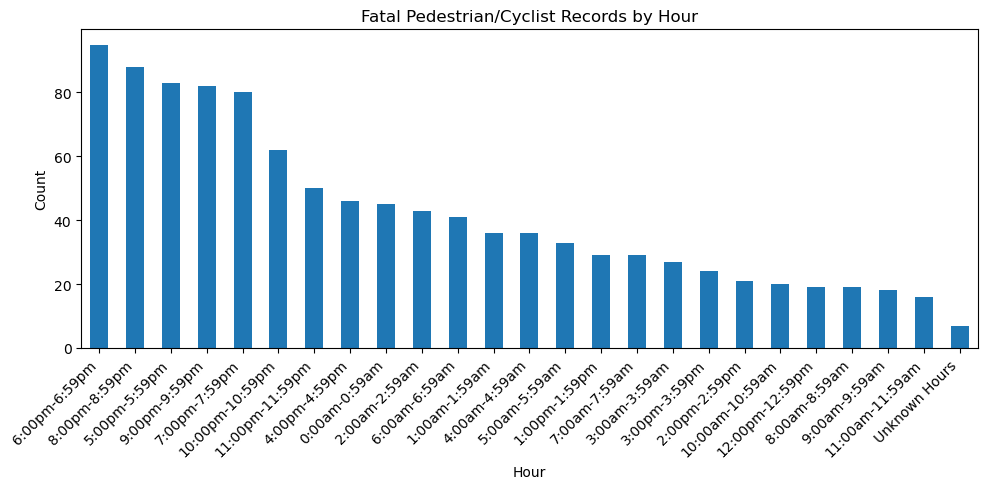

In [19]:
if column_exists("HOURNAME"):
    plot_bar(df["HOURNAME"], "Fatal Pedestrian/Cyclist Records by Hour", xlabel="Hour")


## 5. Victim demographics

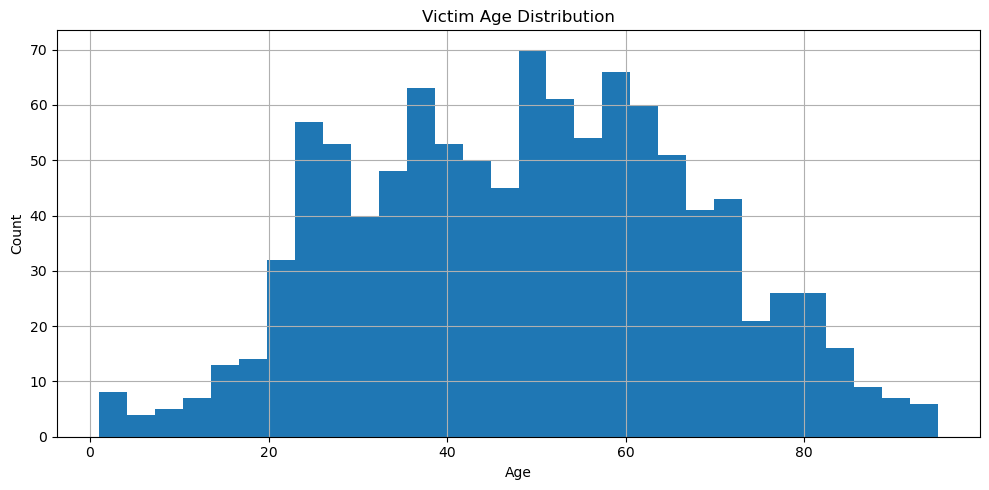

,AGE
count,1049.000000
mean,48.890372
std,19.063484
min,1.000000
25%,35.000000
50%,50.000000
75%,63.000000
max,95.000000


In [20]:
if column_exists("AGE"):
    age = pd.to_numeric(df["AGE"], errors="coerce")

    plt.figure(figsize=(10, 5))
    age.hist(bins=30)
    plt.title("Victim Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    display(age.describe().to_frame("AGE"))


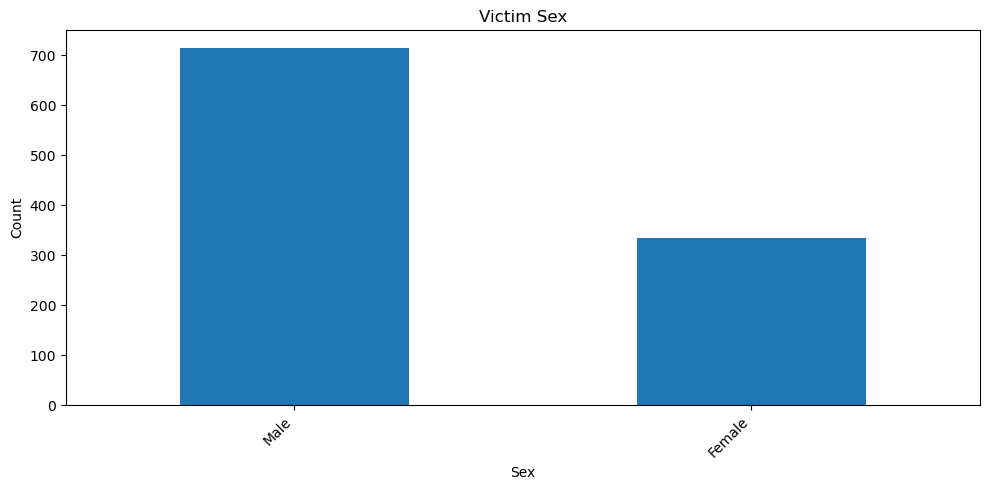

In [21]:
if column_exists("SEXNAME"):
    plot_bar(df["SEXNAME"], "Victim Sex", xlabel="Sex")


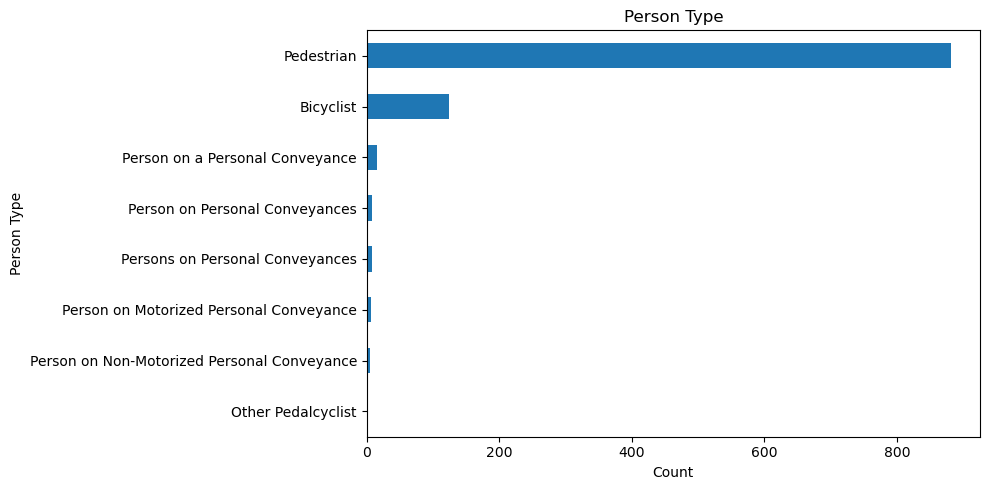

In [22]:
if column_exists("PBPTYPENAME"):
    plot_bar(df["PBPTYPENAME"], "Person Type", xlabel="Person Type", horizontal=True)


## 6. Roadway, infrastructure, and environment

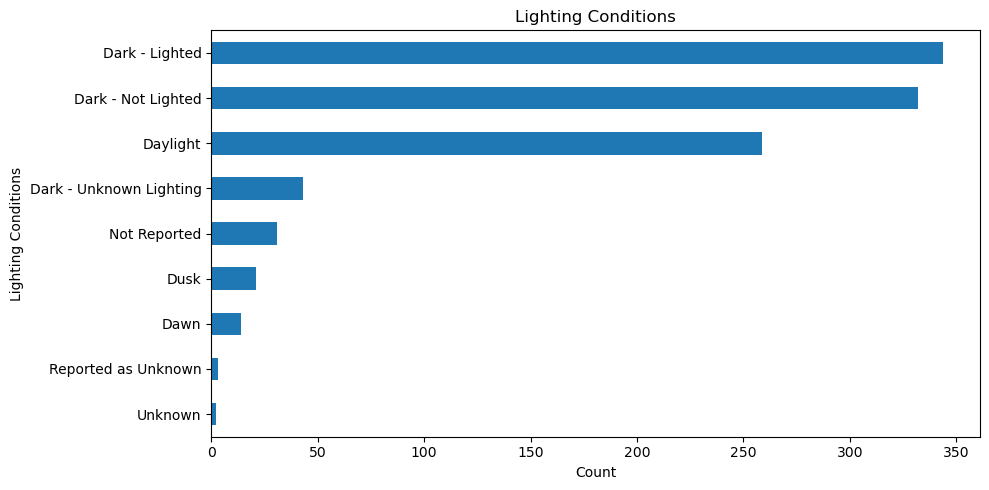

In [23]:
if column_exists("LGT_CONDNAME"):
    plot_bar(df["LGT_CONDNAME"], "Lighting Conditions", xlabel="Lighting Conditions", top_n=15, horizontal=True)


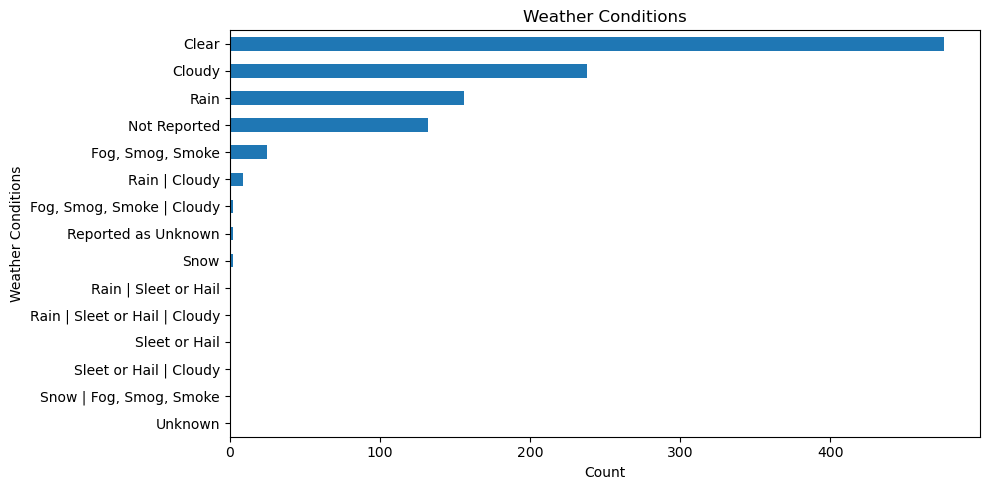

In [24]:
if column_exists("WEATHER"):
    plot_bar(df["WEATHER"], "Weather Conditions", xlabel="Weather Conditions", top_n=15, horizontal=True)


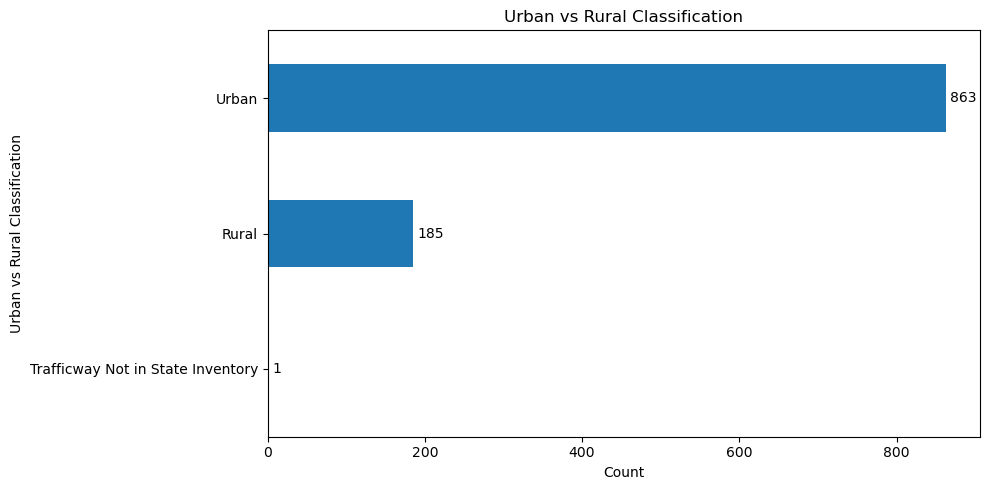

In [31]:
if column_exists("RUR_URBNAME"):
    plot_bar(df["RUR_URBNAME"], "Urban vs Rural Classification", xlabel="Urban vs Rural Classification", top_n=15, horizontal=True)


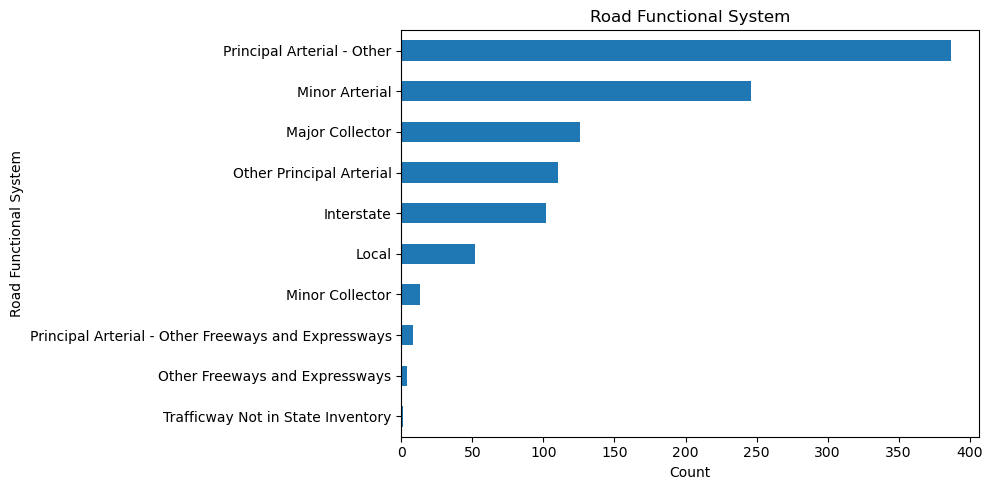

In [26]:
if column_exists("FUNC_SYSNAME"):
    plot_bar(df["FUNC_SYSNAME"], "Road Functional System", xlabel="Road Functional System", top_n=15, horizontal=True)


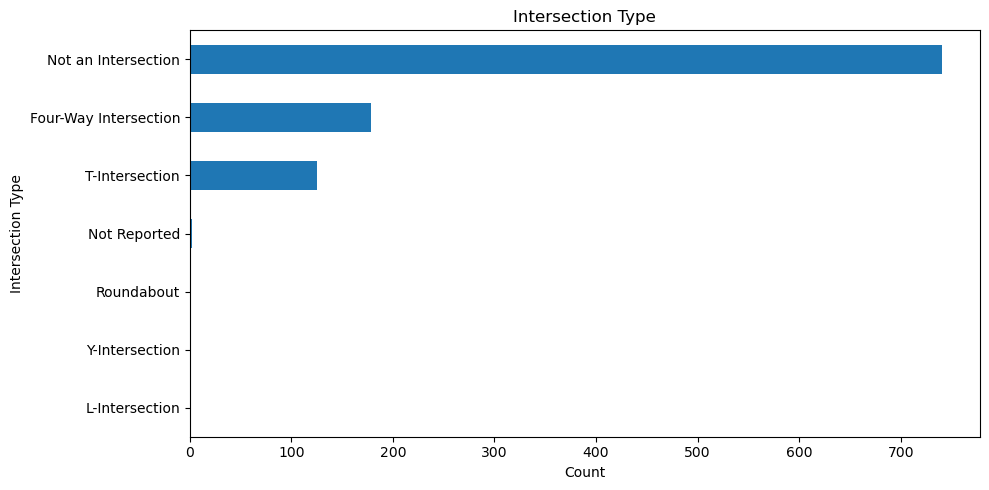

In [27]:
if column_exists("TYP_INTNAME"):
    plot_bar(df["TYP_INTNAME"], "Intersection Type", xlabel="Intersection Type", top_n=15, horizontal=True)


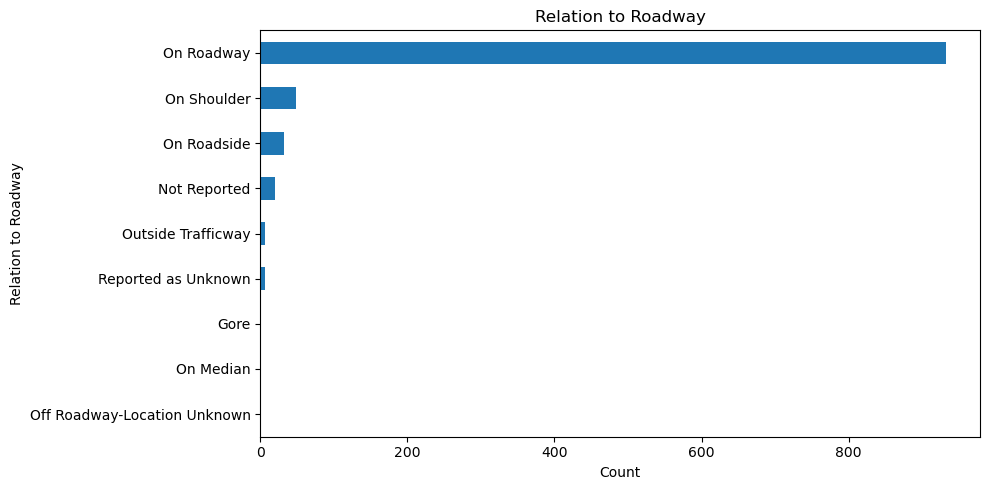

In [28]:
if column_exists("REL_ROADNAME"):
    plot_bar(df["REL_ROADNAME"], "Relation to Roadway", xlabel="Relation to Roadway", top_n=15, horizontal=True)


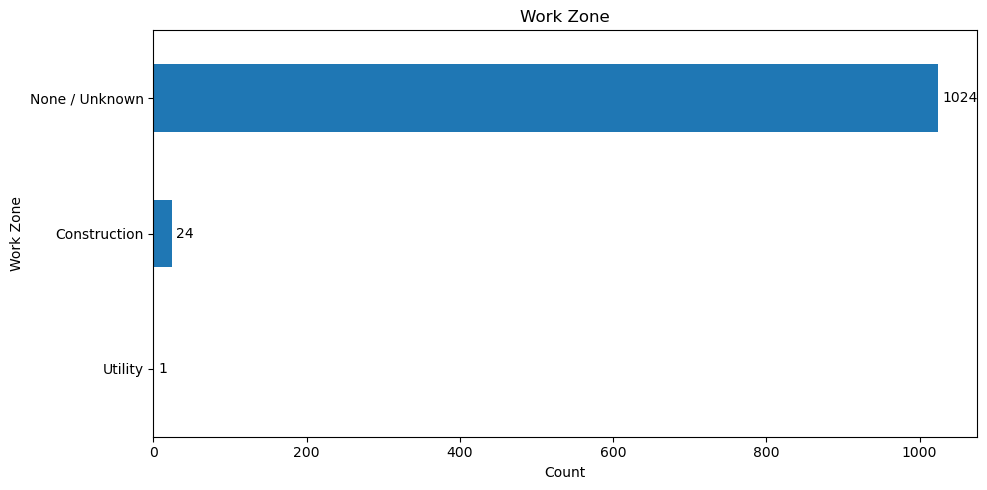

In [32]:
if column_exists("WRK_ZONENAME"):
    plot_bar(df["WRK_ZONENAME"], "Work Zone", xlabel="Work Zone", top_n=15, horizontal=True)


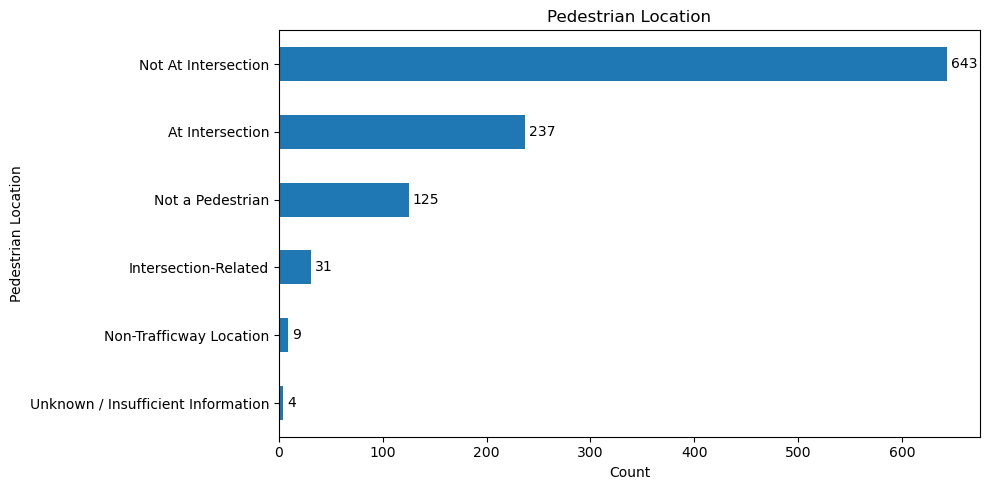

In [33]:
if column_exists("PEDLOCNAME"):
    plot_bar(df["PEDLOCNAME"], "Pedestrian Location", xlabel="Pedestrian Location", top_n=15, horizontal=True)


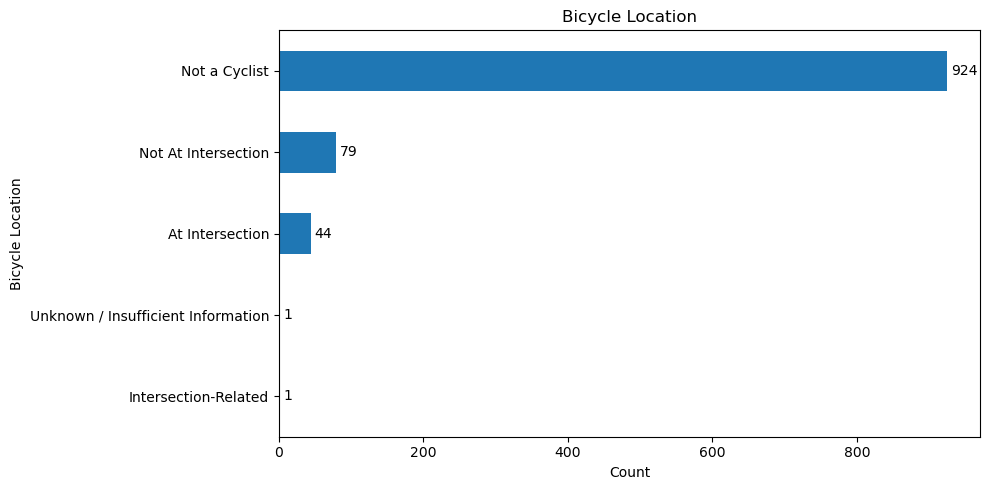

In [34]:
if column_exists("BIKELOCNAME"):
    plot_bar(df["BIKELOCNAME"], "Bicycle Location", xlabel="Bicycle Location", top_n=15, horizontal=True)


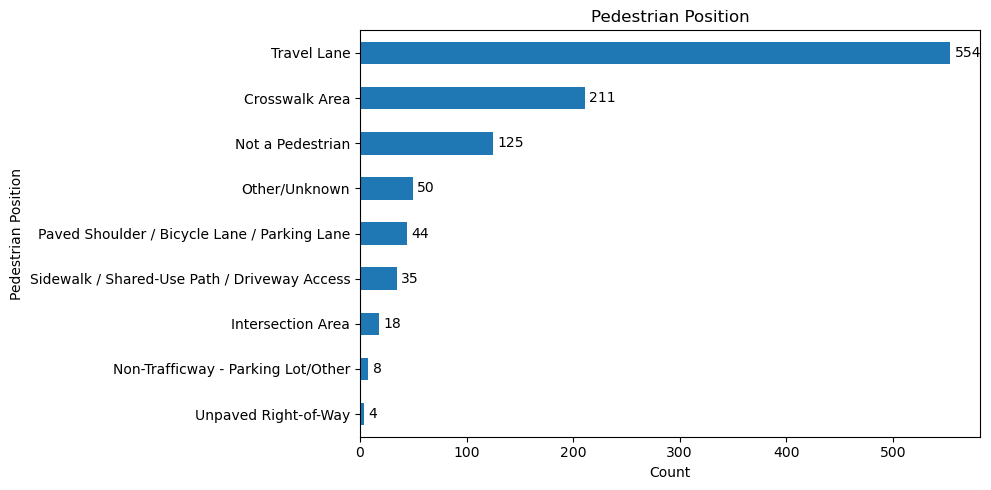

In [35]:
if column_exists("PEDPOSNAME"):
    plot_bar(df["PEDPOSNAME"], "Pedestrian Position", xlabel="Pedestrian Position", top_n=15, horizontal=True)


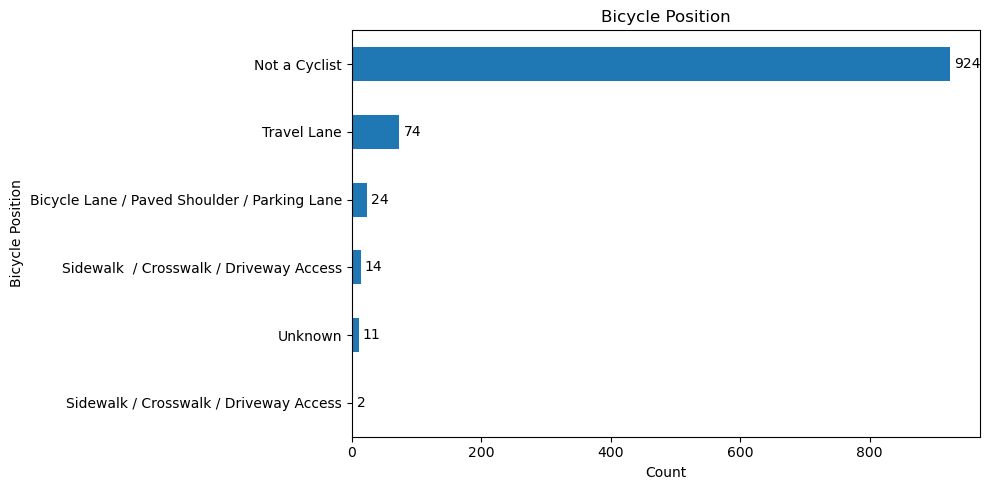

In [36]:
if column_exists("BIKEPOSNAME"):
    plot_bar(df["BIKEPOSNAME"], "Bicycle Position", xlabel="Bicycle Position", top_n=15, horizontal=True)


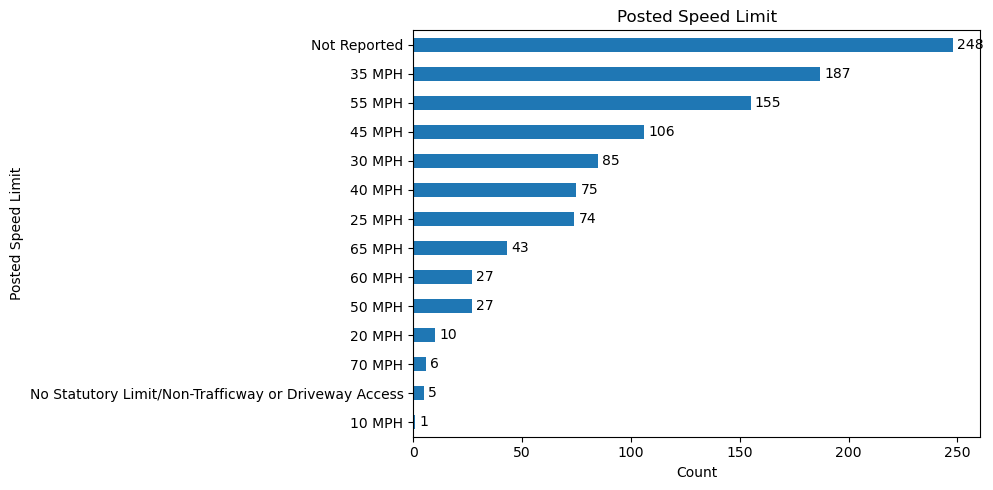

In [37]:
if column_exists("VSPD_LIMNAME"):
    plot_bar(df["VSPD_LIMNAME"], "Posted Speed Limit", xlabel="Posted Speed Limit", top_n=15, horizontal=True)


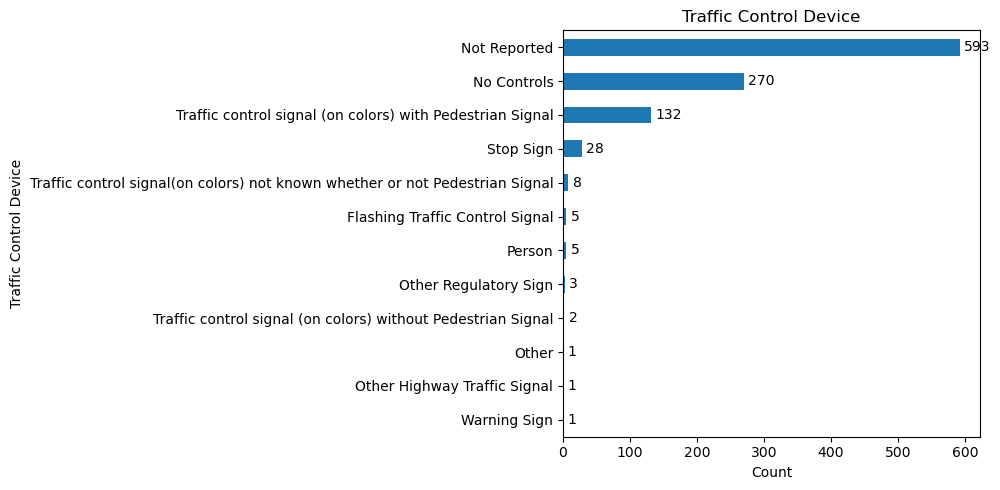

In [38]:
if column_exists("VTRAFCONNAME"):
    plot_bar(df["VTRAFCONNAME"], "Traffic Control Device", xlabel="Traffic Control Device", top_n=15, horizontal=True)


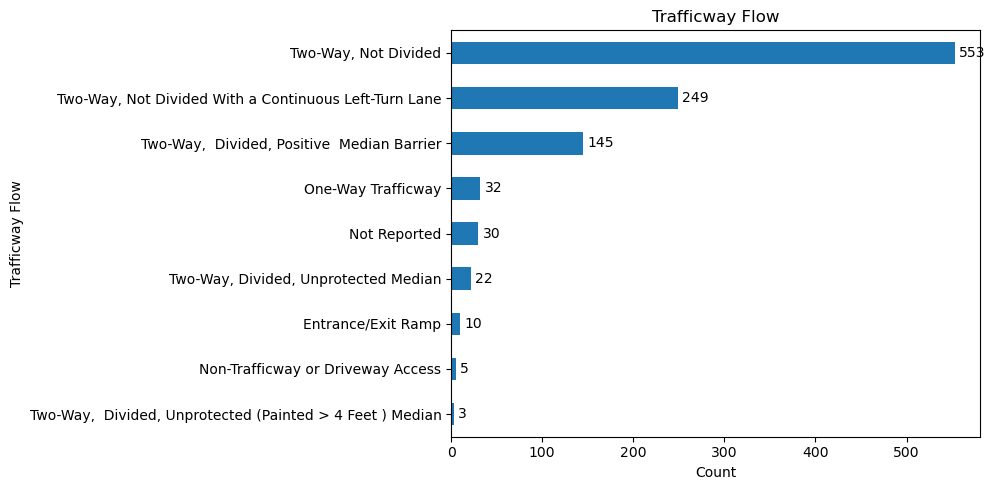

In [39]:
if column_exists("VTRAFWAYNAME"):
    plot_bar(df["VTRAFWAYNAME"], "Trafficway Flow", xlabel="Trafficway Flow", top_n=15, horizontal=True)


## 7. Spatial overview

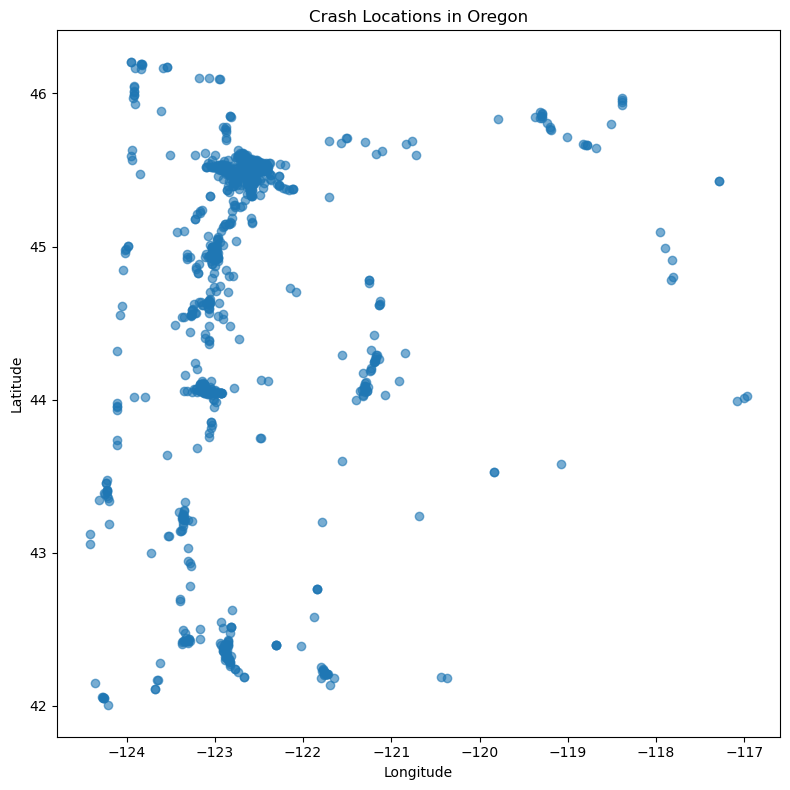

Spatial records plotted: 1,049


In [40]:
if {"LATITUDE", "LONGITUD"}.issubset(df.columns):
    spatial = df.copy()
    spatial["LATITUDE"] = pd.to_numeric(spatial["LATITUDE"], errors="coerce")
    spatial["LONGITUD"] = pd.to_numeric(spatial["LONGITUD"], errors="coerce")

    spatial = spatial.dropna(subset=["LATITUDE", "LONGITUD"])

    # Basic Oregon sanity bounds
    spatial = spatial[
        spatial["LATITUDE"].between(41, 47) &
        spatial["LONGITUD"].between(-125, -116)
    ]

    plt.figure(figsize=(8, 8))
    plt.scatter(spatial["LONGITUD"], spatial["LATITUDE"], alpha=0.6)
    plt.title("Crash Locations in Oregon")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()

    print(f"Spatial records plotted: {len(spatial):,}")


## 8. Cross-tabs for modeling ideas

PBPTYPENAME,Bicyclist,Other Pedalcyclist,Pedestrian,Person on Motorized Personal Conveyance,Person on Non-Motorized Personal Conveyance,Person on Personal Conveyances,Person on a Personal Conveyance,Persons on Personal Conveyances
YEAR,,,,,,,,
2015,8,0,73,0,0,0,0,5
2016,11,0,79,0,0,0,0,3
2017,10,0,74,0,0,3,0,0
2018,9,0,78,0,0,2,0,0
2019,11,0,87,0,0,3,0,0
2020,15,0,72,4,3,0,0,0
2021,18,0,91,2,2,0,0,0
2022,13,1,126,0,0,0,3,0
2023,18,0,105,0,0,0,8,0


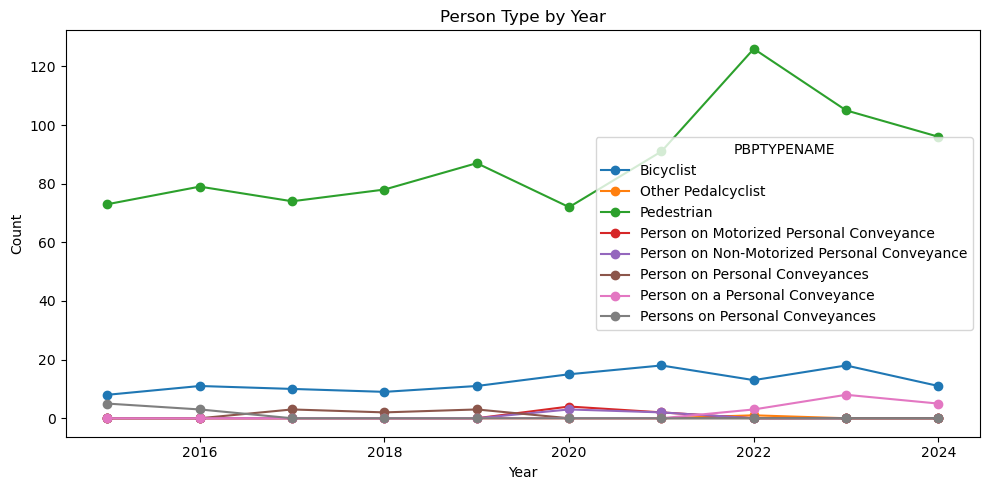

In [41]:
if {"YEAR", "PBPTYPENAME"}.issubset(df.columns):
    year_type = pd.crosstab(df["YEAR"], df["PBPTYPENAME"])
    display(year_type)

    year_type.plot(figsize=(10, 5), marker="o")
    plt.title("Person Type by Year")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


In [42]:
if {"LGT_CONDNAME", "PBPTYPENAME"}.issubset(df.columns):
    light_type = pd.crosstab(df["LGT_CONDNAME"], df["PBPTYPENAME"])
    display(light_type)


PBPTYPENAME,Bicyclist,Other Pedalcyclist,Pedestrian,Person on Motorized Personal Conveyance,Person on Non-Motorized Personal Conveyance,Person on Personal Conveyances,Person on a Personal Conveyance,Persons on Personal Conveyances
LGT_CONDNAME,,,,,,,,
Dark - Lighted,19,0,313,1,2,2,5,2
Dark - Not Lighted,24,0,299,1,0,2,3,3
Dark - Unknown Lighting,2,0,38,0,1,0,2,0
Dawn,2,0,11,0,0,0,0,1
Daylight,67,1,176,3,2,4,4,2
Dusk,5,0,16,0,0,0,0,0
Not Reported,5,0,24,1,0,0,1,0
Reported as Unknown,0,0,2,0,0,0,1,0
Unknown,0,0,2,0,0,0,0,0


In [43]:
if {"RUR_URBNAME", "LGT_CONDNAME"}.issubset(df.columns):
    urban_light = pd.crosstab(df["RUR_URBNAME"], df["LGT_CONDNAME"], normalize="index") * 100
    display(urban_light.round(2))


LGT_CONDNAME,Dark - Lighted,Dark - Not Lighted,Dark - Unknown Lighting,Dawn,Daylight,Dusk,Not Reported,Reported as Unknown,Unknown
RUR_URBNAME,,,,,,,,,
Rural,6.49,52.97,4.86,1.62,25.95,4.32,2.70,0.54,0.54
Trafficway Not in State Inventory,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00,0.00
Urban,38.47,27.11,3.94,1.27,24.33,1.51,3.01,0.23,0.12


In [44]:
if {"VSPD_LIMNAME", "PBPTYPENAME"}.issubset(df.columns):
    speed_type = pd.crosstab(df["VSPD_LIMNAME"], df["PBPTYPENAME"])
    display(speed_type)


PBPTYPENAME,Bicyclist,Other Pedalcyclist,Pedestrian,Person on Motorized Personal Conveyance,Person on Non-Motorized Personal Conveyance,Person on Personal Conveyances,Person on a Personal Conveyance,Persons on Personal Conveyances
VSPD_LIMNAME,,,,,,,,
10 MPH,0,0,1,0,0,0,0,0
20 MPH,1,0,9,0,0,0,0,0
25 MPH,21,0,50,0,1,1,1,0
30 MPH,3,0,75,1,1,1,3,1
35 MPH,14,0,164,1,0,1,5,2
40 MPH,6,0,65,0,1,1,1,1
45 MPH,13,0,89,0,0,0,2,2
50 MPH,0,0,25,0,0,0,1,1
55 MPH,30,0,124,0,0,1,0,0


## 9. Top condition combinations

In [45]:
combo_cols = [
    col for col in [
        "PBPTYPENAME",
        "LGT_CONDNAME",
        "WEATHER",
        "RUR_URBNAME",
        "FUNC_SYSNAME",
        "VSPD_LIMNAME",
        "VTRAFCONNAME"
    ]
    if col in df.columns
]

if len(combo_cols) >= 2:
    combos = (
        df.groupby(combo_cols)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(20)
    )

    display(combos)


,PBPTYPENAME,LGT_CONDNAME,WEATHER,RUR_URBNAME,FUNC_SYSNAME,VSPD_LIMNAME,VTRAFCONNAME,count
160,Pedestrian,Dark - Lighted,Clear,Urban,Principal Arterial - Other,35 MPH,Not Reported,11
211,Pedestrian,Dark - Lighted,Cloudy,Urban,Principal Arterial - Other,35 MPH,Not Reported,9
476,Pedestrian,Dark - Unknown Lighting,Not Reported,Urban,Principal Arterial - Other,Not Reported,Not Reported,8
332,Pedestrian,Dark - Not Lighted,Clear,Urban,Principal Arterial - Other,55 MPH,No Controls,7
349,Pedestrian,Dark - Not Lighted,Cloudy,Rural,Principal Arterial - Other,55 MPH,No Controls,6
328,Pedestrian,Dark - Not Lighted,Clear,Urban,Principal Arterial - Other,45 MPH,No Controls,6
473,Pedestrian,Dark - Unknown Lighting,Not Reported,Urban,Minor Arterial,Not Reported,Not Reported,6
376,Pedestrian,Dark - Not Lighted,Cloudy,Urban,Principal Arterial - Other,45 MPH,Not Reported,6
306,Pedestrian,Dark - Not Lighted,Clear,Urban,Interstate,55 MPH,Not Reported,5
325,Pedestrian,Dark - Not Lighted,Clear,Urban,Principal Arterial - Other,35 MPH,Not Reported,5


## 10. Modeling readiness notes

In [46]:
modeling_notes = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "unique_values": [df[col].nunique(dropna=False) for col in df.columns],
    "missing_pct": [df[col].isna().mean() * 100 for col in df.columns]
}).sort_values(["missing_pct", "unique_values"], ascending=[False, False])

modeling_notes


,column,dtype,unique_values,missing_pct
32,MEDIAN_INCOME,float64,484,0.571973
36,PCT_HISPANIC,float64,492,0.095329
34,PCT_WHITE,float64,491,0.095329
37,PCT_TRANSIT_WALK_COMMUTE,float64,461,0.095329
35,PCT_BLACK,float64,369,0.095329
17,LONGITUD,float64,997,0.000000
16,LATITUDE,float64,990,0.000000
30,GEOID,int64,492,0.000000
0,ST_CASE,int64,490,0.000000
33,TOTAL_POPULATION,int64,465,0.000000


## EDA takeaways to write up

Use the outputs above to summarize:

- Which years, months, days, or hours have higher counts.
- Whether fatal records are mostly pedestrian, cyclist, or mixed.
- Which lighting, weather, speed limit, road class, and traffic control categories dominate.
- Whether spatial points cluster around Oregon urban corridors.
- Which variables are complete enough and meaningful enough for modeling.
- Which limitations should be documented before moving to regression or ML.
